In [1]:
%load_ext autoreload
%autoreload 2

import requests, os, zipfile, re
import pandas as pd, numpy as np
import peartree as pt, networkx as nx
from numba import jit
from dotenv import load_dotenv

In [2]:
# load api keys
load_dotenv()

API_KEY_ORS = os.getenv("OPENROUTESERVICE")

In [ ]:
def on_the_road_route_btwn_multiple_points(profile, points):

	"""
	Calculates a route between multiple points using the OpenRouteService API.

	Parameters:
	profile (str): The travel mode ('driving-car', 'foot-walking', or 'wheelchair').
	points (iterable): A list of tuples with (latitude, longitude) for each point.

	Returns:
	dict: The route details as a json.
	"""

    
	# Limit support to 3 profiles
	assert profile in ["driving-car","foot-walking","wheelchair"], "Unsupported profile."

	if len(points) < 2:
		raise ValueError("Must have at least 2 points.")
	
	if not isinstance(points, (list, tuple, pd.Series, np.array)):
		raise ValueError("Must be list or similar iterable.")

    # ensure all the points are tuples with two elements (latitude, longitude)
	if not all(isinstance(point, tuple) and len(point) == 2 for point in points):
		raise ValueError("Each point must be a tuple with two elements: (latitude, longitude)")

	# reverse the order of the coordinates to (long, lat) as required by ORS
	points = [[point[1], point[0]] for point in points]  # Reverse the order (longitude, latitude)

	body = {
		'coordinates': points
	}

	headers = {
		'Accept': 'application/json, application/geo+json, application/gpx+xml, img/png; charset=utf-8',
		'Authorization': API_KEY_ORS,
		'Content-Type': 'application/json; charset=utf-8'
	}

	# Make the request to the API
	resp = requests.post(
		f'https://api.openrouteservice.org/v2/directions/{profile}', 
		json=body, 
		headers=headers
	)

	# Check for successful response
	if resp.status_code != 200:
		try:
			payload = resp.json()  # Try to parse the error response as JSON
			error_code = payload.get('error', {}).get('code', 'Unknown code')
			error_message = payload.get('error', {}).get('message', 'Unknown error message')
		except ValueError:
			error_code = 'Unknown code'
			error_message = 'Unknown error message'

		raise Exception(f"HTTP {resp.status_code}: {resp.reason}. Error code: {error_code}. Error message: {error_message}")

	# Parse the response payload
	try:
		payload = resp.json()
	except ValueError:
		raise ValueError(f"Failed to parse JSON response from OpenRouteService API: {resp.text}")

	return payload


def driving_route(points):
	return on_the_road_route_btwn_multiple_points(profile='driving-car', points=points)

def walking_route(points):
	return on_the_road_route_btwn_multiple_points(profile='foot-walking', points=points)

def wheelchair_route(points):
	return on_the_road_route_btwn_multiple_points(profile='wheelchair', points=points)


def estimate_road_route_distance_duration(route):
	"""Calculates the total distance (metres) and duration (seconds) of a route based on the JSON from the OpenRouteService API."""
	distance_duration_pairs = [segment['summary'] for segment in route['routes']]
	total_distance_duration = {key: sum(pair[key] for pair in distance_duration_pairs) for key in ['distance', 'duration']}
	return total_distance_duration

# KL GTFS data

In [3]:
# Get data from government API
def fetch_gtfs_data(category):

    # Download the GTFS ZIP file from the API
    url = f"https://api.data.gov.my/gtfs-static/prasarana?category={category}"
    response = requests.get(url)

    if response.status_code != 200:
        print(response.status_code)
        raise Exception(f"Failed to fetch GTFS data for category '{category}'")
    
    # Save the content of the response as a zip file
    file_name = f'gtfs_{category}.zip'
    with open(file_name, 'wb') as f:
        f.write(response.content)
        print(f"GTFS data saved as {file_name}.")

    
def gtfs_zip_to_dfs(category):

    file_name = f'gtfs_{category}.zip'
    gtfs_data = {}

    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        files = [f for f in zip_ref.namelist() if f.endswith('.txt')]
        
        for file in files:
            with zip_ref.open(file) as f:
                gtfs_data[file.replace('.txt', '')] = pd.read_csv(f, encoding='utf-8')

    print('GTFS files loaded: ', ', '.join([f.replace('.txt','') for f in files]))

    return gtfs_data

fetch_gtfs_data('rapid-rail-kl')

GTFS data saved as gtfs_rapid-rail-kl.zip.


In [4]:
# Load into dfs
gtfs = gtfs_zip_to_dfs('rapid-rail-kl')

# Access the data
stops = gtfs.get('stops')
routes = gtfs.get('routes')
trips = gtfs.get('trips')
freqs = gtfs.get('frequencies')
stti = gtfs.get('stop_times')
# shapes = gtfs.get('shapes')

stops.loc[stops['stop_id'].str.startswith('KG'), 'route_id'] = 'KGL'  # Data quality issue

GTFS files loaded:  agency, calendar, frequencies, routes, shapes, stop_times, stops, trips


In [ ]:
nodes = stops[['stop_id','stop_name','stop_lat','stop_lon','route_id']].copy()
nodes = pd.merge(nodes, routes[['route_id','route_color','route_text_color']], 'left', 'route_id')
nodes.index = nodes['stop_id'].values
nodes.sample(5, random_state=0)

,stop_id,stop_name,stop_lat,stop_lon,route_id,route_color,route_text_color
MR2,MR2,TUN SAMBANTHAN,3.131320,101.690850,MR,84bd00,FFFFFF
SP29,SP29,PUCHONG PRIMA,2.999808,101.596692,PH,76232f,FFFFFF
PY12,PY12,SRI DELIMA,3.207108,101.665749,PYL,FFCD00,FFFFFF
SP25,SP25,PUSAT BANDAR PUCHONG,3.033194,101.616057,PH,76232f,FFFFFF
KG22,KG22,MALURI,3.123623,101.727809,KGL,047940,FFFFFF


In [9]:
edges = stti[['trip_id','route_id','stop_id','stop_sequence','arrival_time','departure_time']].copy()
edges = edges.sort_values(['trip_id','stop_sequence']).copy()
# sched = sched[sched['trip_id'].str.startswith('MRL_MonFri_')].copy()

# Format datetimes
edges['arrival_time'] = pd.to_datetime(edges['arrival_time'], format='%H:%M:%S')
edges['departure_time'] = pd.to_datetime(edges['departure_time'], format='%H:%M:%S')

# Get time
edges['next_stop_id'] = edges.groupby(['trip_id'])['stop_id'].shift(-1)
edges['next_departure'] = edges.groupby(['trip_id'])['departure_time'].shift(-1)
edges['travel_time'] = (edges['next_departure'] - edges['departure_time']).dt.seconds

edges = edges[['trip_id','route_id','stop_id','next_stop_id','travel_time','stop_sequence']].dropna(subset=['next_stop_id'])

# Just keep weekday times
edges = edges[edges['trip_id'].str.split('_').str[1]=='MonFri'].copy()


#### check if travel time is the same in both directions

# pair up stops as sorted tuples so A->B and B->A are normalized
edges['stop_pair'] = edges.apply(lambda row: tuple(sorted([row['stop_id'], row['next_stop_id']])), axis=1)

# group by the stop pairs and check for unique travel times
inconsistent_pairs = edges.groupby(['route_id', 'stop_pair'])['travel_time'].nunique().reset_index()
inconsistent_pairs = inconsistent_pairs[inconsistent_pairs['travel_time'] > 1]
if inconsistent_pairs.empty:
    print("All A -> B and B -> A travel times are consistent.\nWe can just use an undirected network.")
else:
    print("\033[91mA -> B and B -> A travel times are NOT consistent.\nDirected network needed.\n\033[0m")
    print(inconsistent_pairs[['route_id', 'stop_pair']].head(3))
del inconsistent_pairs

# Simplify and format
edges = edges.drop(columns=['stop_pair','trip_id','stop_sequence'])
edges = edges[['stop_id','next_stop_id'] + [c for c in edges.columns if c not in ['stop_id','next_stop_id']]].drop_duplicates()
edges = pd.merge(edges, routes[['route_short_name','route_color']], 'left', None, 'route_id', 'route_short_name').drop(columns=['route_short_name'])


A -> B and B -> A travel times are NOT consistent.
Directed network needed.

  route_id     stop_pair
3      AGL  (AG11, AG12)
4      AGL  (AG12, AG13)
5      AGL  (AG13, AG14)


In [10]:
nodes.head(2)

,stop_id,stop_name,stop_lat,stop_lon,route_id,route_color,route_text_color
AG18,AG18,AMPANG,3.150318,101.760049,AG,e57200,FFFFFF
AG17,AG17,CAHAYA,3.140575,101.756677,AG,e57200,FFFFFF


In [11]:
edges.head(2)

,stop_id,next_stop_id,route_id,travel_time,route_color
0,AG18,AG17,AGL,123.0,e57200
1,AG17,AG16,AGL,72.0,e57200


In [12]:
# Average waiting time can be estimated as 50% of the headway (i.e. time between trains)
freqs['line'] = freqs['trip_id'].str.split('_').str[0]
freqs['dow'] = freqs['trip_id'].str.split('_').str[1]
headway = freqs.groupby(['line','dow'])['headway_secs'].max().unstack()
headway.T

line,AGL,BRT,KGL,KJL,MRL,PYL,SPL
dow,,,,,,,
MonFri,300,480,600,420,600,840,300
Sat,300,360,600,420,720,600,300
Sun,300,360,600,420,720,600,300


## Create network

In [13]:
# Init graph
G = nx.DiGraph(name='rapid-rail-kl')

# Add nodes - data structure is a list of tuples of (node_id, {attribute_dict})
node_tuples = list(nodes.to_dict(orient='index').items())
G.add_nodes_from(node_tuples)

# Add edges - data structure is a list of tuples of (from_node, to_node, {attribute_dict})
edge_tuples = [
    (
        row['stop_id'],
        row['next_stop_id'],
        {k: v for k, v in row.items() if k not in ('stop_id', 'next_stop_id')}
    )
    for row in edges.to_dict(orient='records')
]
G.add_edges_from(edge_tuples)

In [14]:
G.edges[('KJ10','KJ9')]

{'route_id': 'KJL', 'travel_time': 150.0, 'route_color': 'D50032'}

In [15]:
G.edges[('KJ9','KJ10')]

{'route_id': 'KJL', 'travel_time': 130.0, 'route_color': 'D50032'}

In [16]:
# haversine formula
def haversine(latlon1, latlon2):
    # Extract latitudes and longitudes for each point
    lat1, lon1 = latlon1
    lat2, lon2 = latlon2

    R = 6371.0  # earth radius (km)

    # convert latlong from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1  # N-S distance
    dlon = lon2 - lon1  # E-W distance

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = int(round(1000 * R * c))   # distance in metres, rounded to nearest metre

    return distance

In [17]:
from scipy.spatial.distance import pdist

# Compute pairwise distances using pdist (Euclidean by default)
distances = pdist(stops[['stop_lat', 'stop_lon']].values, metric=haversine)

# Get the indices of the unique pairs (upper triangle)
n = stops.shape[0]  # number of stations
pairs = [
	(stops.iloc[i]['stop_id'], stops.iloc[j]['stop_id']) 
	for i in range(n) for j in range(i + 1, n)
]
del n

# Create the DataFrame directly from pairs and distances
distances = pd.DataFrame({
    'A': [pair[0] for pair in pairs],
    'B': [pair[1] for pair in pairs],
    'dist': distances
})

distances = distances.sort_values('dist')

# Heuristics for valid interchanges
# 1. Not too far apart
# 2. Two stations on different lines
distances = distances[
	(distances['dist'] < 500) &  # Not too far away
	(distances['A'].str.replace(r'[^a-zA-Z]', '', regex=True) != distances['B'].str.replace(r'[^a-zA-Z]', '', regex=True))  # Not on the same line
].reset_index(drop=True)
# distances['from'] = distances['A'].map(stops.set_index('stop_id')['search'])
# distances['to'] = distances['B'].map(stops.set_index('stop_id')['search'])
# distances['from_latlong'] = distances['A'].map(stops.set_index('stop_id')['search'])
# distances['to_latlong'] = distances['B'].map(stops.set_index('stop_id')['search'])

In [18]:
for side in ('A','B'):
	distances = pd.merge(
		distances,
		stops.set_index('stop_id')[['search','stop_lat','stop_lon']].rename(columns=lambda x: f'{side}__{x}' if x != 'stop_id' else x),
		'left',
		left_on=side,
		right_index=True,
	)

<Axes: >

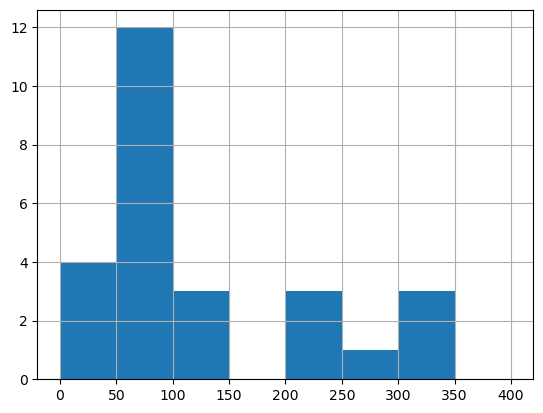

In [19]:
distances[distances['dist'] > 10].dist.hist(bins=[i*50 for i in range(9)])

In [20]:
distances[distances['A']=='KJ9']

,A,B,dist,A__search,A__stop_lat,A__stop_lon,B__search,B__stop_lat,B__stop_lon
33,KJ9,PY20,294.0,LRT AMPANG PARK,3.159894,101.719017,MRT AMPANG PARK,3.16225,101.71781
34,KJ9,PY21,317.0,LRT AMPANG PARK,3.159894,101.719017,MRT PERSIARAN KLCC,3.15712,101.71834


In [21]:
distances[distances['dist'] > 0].head(10)

,A,B,dist,A__search,A__stop_lat,A__stop_lon,B__search,B__stop_lat,B__stop_lon
11,KG04,PY01,23.0,MRT KWASA DAMANSARA,3.176146,101.572052,MRT KWASA DAMANSARA,3.176332,101.572146
12,KJ37,SP31,24.0,LRT PUTRA HEIGHTS,2.996227,101.575462,LRT PUTRA HEIGHTS,2.996016,101.575521
13,KJ14,KG16,33.0,LRT PASAR SENI,3.142439,101.695310,MRT PASAR SENI,3.142293,101.695564
14,SP16,PY29,39.0,LRT SUNGAI BESI,3.063842,101.708062,MRT SUNGAI BESI,3.063737,101.708400
15,KJ31,BRT7,50.0,LRT USJ 7,3.054956,101.592194,BRT USJ7,3.055300,101.591900
16,SP9,MR4,56.0,LRT HANG TUAH,3.140012,101.705984,MR HANG TUAH,3.140511,101.706029
17,AG9,MR4,56.0,LRT HANG TUAH,3.140012,101.705984,MR HANG TUAH,3.140511,101.706029
18,KG20,PY23,58.0,MRT TUN RAZAK EXCHANGE,3.142403,101.720156,MRT TUN RAZAK EXCHANGE,3.142890,101.720340
19,AG7,KJ13,69.0,LRT MASJID JAMEK,3.149270,101.696377,LRT MASJID JAMEK,3.149714,101.696815
20,KJ13,SP7,69.0,LRT MASJID JAMEK,3.149714,101.696815,LRT MASJID JAMEK,3.149270,101.696377


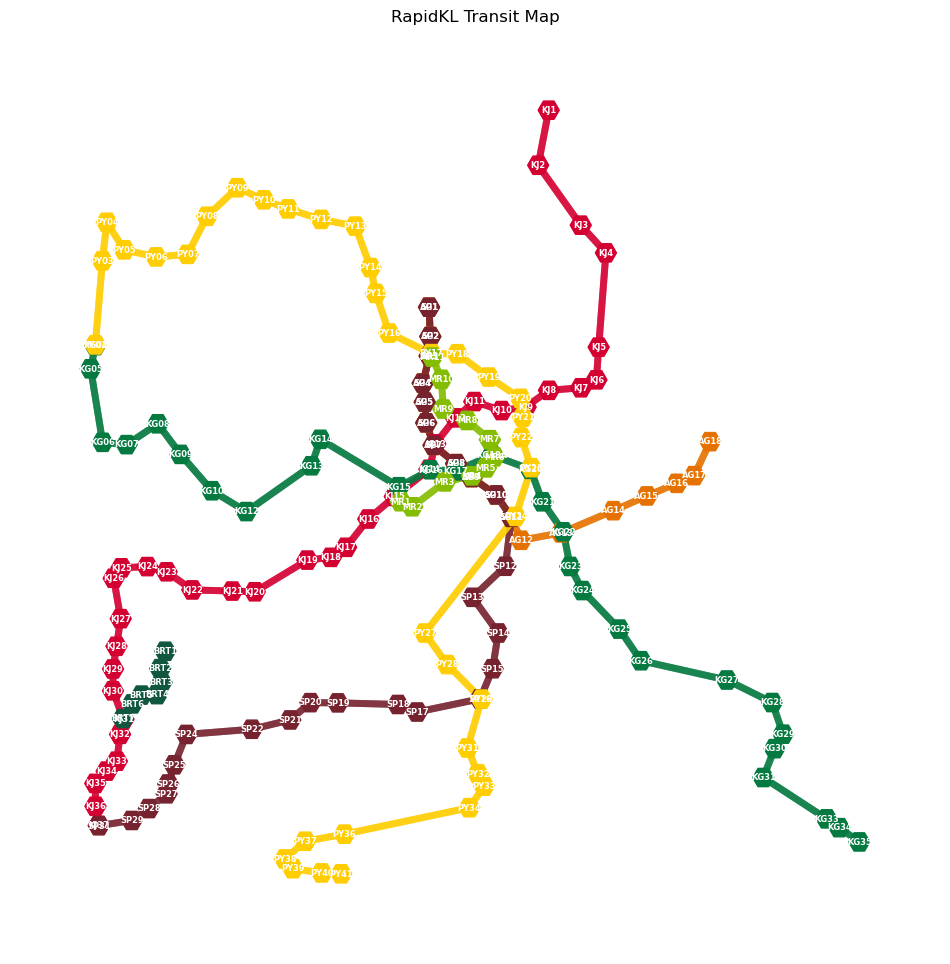

In [22]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_network_centered(G, centre_map_at_node='KG17', node_size=230, font_size=6, edge_width=5, fig_size=12):
    # Get node colors based on 'route_color' attribute
    node_colors = [f"#{data.get('route_color', 'gray')}" for _, data in G.nodes(data=True)]
    edge_colors = [f"#{data.get('route_color', 'gray')}" for _, _, data in G.edges(data=True)]

    # Get the latitudes and longitudes from the nodes' attributes
    latitudes = [data['stop_lat'] for _, data in G.nodes(data=True)]
    longitudes = [data['stop_lon'] for _, data in G.nodes(data=True)]

    # Get the latitude and longitude of the target node
    target_lat = G.nodes[centre_map_at_node]['stop_lat']
    target_lon = G.nodes[centre_map_at_node]['stop_lon']

    # Compute the normalized coordinates relative to the target node
    latitudes_relative  = [lat - target_lat for lat in latitudes]
    longitudes_relative = [lon - target_lon for lon in longitudes]

    # Normalize the latitudes and longitudes (keeping relative distances)
    min_lat, max_lat = min(latitudes_relative), max(latitudes_relative)
    min_lon, max_lon = min(longitudes_relative), max(longitudes_relative)
    normalized_lat = np.array([(lat - min_lat) / (max_lat - min_lat) for lat in latitudes_relative]) ** 1.8
    normalized_lon = np.array([(lon - min_lon) / (max_lon - min_lon) for lon in longitudes_relative]) ** 1.5

    # Scale the coordinates to fit within the plot
    pos = {node: (fig_size * lon, fig_size * lat) for node, lat, lon in zip(G.nodes(), normalized_lat, normalized_lon)}

    # Create the plot
    plt.figure(figsize=(fig_size, fig_size))

    # Draw the nodes, edges, and labels
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors, node_shape='H')
    nx.draw_networkx_edges(G, pos, width=edge_width, edge_color=edge_colors, alpha=0.7, arrows=False)
    nx.draw_networkx_labels(G, pos, font_size=font_size, font_color='white', font_weight='bold')

    # Title and display
    plt.title(f"RapidKL Transit Map")
    plt.axis('off')  # Hide the axes
    plt.show()

# Example usage:
plot_network_centered(G, centre_map_at_node='KG17')


# Create a class

In [ ]:
class GTFSGraph(nx.DiGraph):
    
    def __init__(self, zip_path):

        '''Initializes the GTFSGraph with the path to the GTFS ZIP file.'''
        super().__init__()

        self.transfer_connection_limit = 50  # metres
        self.default_transfer_time_penalty = 4 * 60  # seconds
        
        # Unpack GTFS data
        gtfs = self.unpack_gtfs(zip_path)
        self.stops_df = gtfs['stops']
        self.routes_df = gtfs['routes']
        self.stop_times_df = gtfs['stop_times']
        self.frequencies_df = gtfs['frequencies']
        del gtfs
        
        # Build the graph
        self.add_nodes_from_stops()
        self.add_edges_from_stop_times()
        self.add_route_attributes()

    def unpack_gtfs(self, zip_path):
        '''Unzips the GTFS file and returns a dict of dfs.'''
        return gtfs_zip_to_dfs(zip_path)

    def add_nodes_from_stops(self):
        '''Adds nodes to the graph from stops.txt'''
        for _, row in self.stops_df.iterrows():
            self.add_node(row['stop_id'], 
                         stop_name=row['stop_name'], 
                         stop_lat=row['stop_lat'], 
                         stop_lon=row['stop_lon'])

    def add_edges_from_stop_times(self):
        '''Adds directed edges between stops based on stop_times.txt.'''
        for _, row in self.stop_times_df.rows():
            pass  # TODO

    def add_node_attributes(self):
        '''Add info to nodes'''
        pass  # TODO

    def add_edge_attributes(self):
        '''Add info to edges'''
        pass  # TODO

    def add_transfer_connections(self, threshold_m=50):
        '''Create links between stops on different lines'''
        pass  # TODO


# Example usage
zip_path = 'path_to_your_gtfs.zip'  # Provide the path to your GTFS ZIP file
G = GTFSGraph(zip_path)


## Peartree experimentation

Problems:
1. not clear how start_time and end_time affect the computation of stop_cost
2. using deprecated .iteritems which causes problems with newer versions of pandas

In [ ]:
G = pt.load_feed_as_graph(
	pt.get_representative_feed(f'gtfs_rapid-rail-kl.zip'),
	start_time = 7 * 3600, end_time = 15 * 3600,
	name = 'RAPID',  # node name prefixes
	existing_graph = None,
	connection_threshold = 50.0,  # max metres for 2 stops to be considered connected
    walk_speed_kmph = 4.5,
	stop_cost_method = lambda x, y, z: z,
    fallback_stop_cost = 5 * 60,  # 5 mins waiting time default
    interpolate_times = True,
    impute_walk_transfers = True,
    use_multiprocessing = False,
)

# Experimenting with routing

Getting the starting point for the pedestrian.
Heuristics:
1. Should be within 1km straight line distance from original location.
2. For each transit line, only pick the closest 1 station

In [15]:
# store station locations as tuples
stations = [(stop_id, stop_lat, stop_lon) for stop_id, stop_lat, stop_lon in zip(stops['stop_id'], stops['stop_lat'], stops['stop_lon'])]

In [16]:
# haversine formula
@jit(nopython=True)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # earth radius (km)

    # convert latlong from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1  # N-S distance
    dlon = lon2 - lon1  # E-W distance

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = int(round(1000 * R * c))   # distance in metres, rounded to nearest metre

    return distance

In [17]:
orig = (3.158378738740368, 101.7084276959602)  # Pelita KLCC
dest = (3.1278264694956586, 101.72497173620582)  # Sunway Velocity

driver_orig = (3.1205620564395713, 101.70879519234487)  # Porsche Sungai Besi

In [18]:
# calculate distances between POI and all stations
def calculate_distances_poi_to_stations(ref_point, stations):
    return {
        station[0]: haversine(ref_point[0], ref_point[1], station[1], station[2])
        for station in stations
    }

In [19]:
orig_dist = calculate_distances_poi_to_stations(orig, stations)
# dest_dist = calculate_distances_poi_to_stations(dest, stations)

In [27]:
# filter stations within distance threshold, rank by proximity, 
# and limit to N stations per transit line
def filter_and_rank_stations(distance_tuples, threshold_metres=1000, max_stations_per_transit_line=1):

    # filter stations within the threshold distance
    filtered = {key: value for key, value in distance_tuples.items() if value <= threshold_metres}
    
    # rank the filtered stations by distance, nearest first
    ranked = dict(sorted(filtered.items(), key=lambda item: item[1]))
    
    # deduplicate: keep up to N stations for each transit line
    seen_prefixes = {}
    deduplicated = {}
    
    for key, value in ranked.items():

        # extract the transit line (alphabetic prefix of station name)
        match = re.match(r'^[a-zA-Z]+', key)
        if match:
            prefix = match.group(0)
            
            # initialize the transit line if it hasn't been seen yet
            if prefix not in seen_prefixes:
                seen_prefixes[prefix] = 0
            
            # if the transit line has fewer than M stations so far, keep the station
            if seen_prefixes[prefix] < max_stations_per_transit_line:
                deduplicated[key] = value
                seen_prefixes[prefix] += 1

    return deduplicated


In [30]:
orig_stations = filter_and_rank_stations(orig_dist, 1000, 2)
orig_stations

{'MR8': 468, 'MR7': 863}

Get the worst case scenario for the driver
- Driving to the passenger's origin, then to the destination.

In [ ]:
G.nodes['KJ15'] ,\
G.nodes['MR1']

({'stop_id': 'KJ15',
  'stop_name': 'KL SENTRAL',
  'stop_lat': 3.13442,
  'stop_lon': 101.68625,
  'route_id': 'KJ',
  'route_color': 'D50032',
  'route_text_color': 'FFFFFF'},
 {'stop_id': 'MR1',
  'stop_name': 'KL SENTRAL',
  'stop_lat': 3.132852,
  'stop_lon': 101.687817,
  'route_id': 'MR',
  'route_color': '84bd00',
  'route_text_color': 'FFFFFF'})

In [329]:
route_btwn_multiple_points('driving-car', (3.13442,101.68625), (3.132852,101.687817))

{'bbox': [101.685049, 3.131474, 101.687723, 3.13504],
 'routes': [{'summary': {'distance': 786.5, 'duration': 91.1},
   'segments': [{'distance': 786.5,
     'duration': 91.1,
     'steps': [{'distance': 272.3,
       'duration': 32.1,
       'type': 11,
       'instruction': 'Head southwest on Jalan Stesen Sentral',
       'name': 'Jalan Stesen Sentral',
       'way_points': [0, 8]},
      {'distance': 105.3,
       'duration': 10.8,
       'type': 13,
       'instruction': 'Keep right onto Jalan Stesen Sentral',
       'name': 'Jalan Stesen Sentral',
       'way_points': [8, 12]},
      {'distance': 408.9,
       'duration': 48.2,
       'type': 12,
       'instruction': 'Keep left onto Jalan Stesen Sentral 5',
       'name': 'Jalan Stesen Sentral 5',
       'way_points': [12, 29]},
      {'distance': 0.0,
       'duration': 0.0,
       'type': 10,
       'instruction': 'Arrive at Jalan Stesen Sentral 5, on the right',
       'name': '-',
       'way_points': [29, 29]}]}],
   'bbox':

In [ ]:
# Worst case scenario
wcs = estimate_road_route_distance_duration(driving_route(driver_orig, orig, dest))
wcs

{'distance': 12114.2, 'duration': 1369.7}